# Métricas de Evaluación y Optimización de Modelos de Clasificación
### Dataset: Breast Cancer Wisconsin - Regresión Logística

Universidad de Guayaquil — Carrera de Ciencia de Datos e Inteligencia Artificial  
**Asignatura:** Aprendizaje Automático  
**Autora:** Kathia Dennisse Parrales Moreno — Grupo 4  
**Fecha:** 11 de junio del 2026


**Contenido del Notebook:**
1. Carga del dataset y exploración inicial
2. Entrenamiento del modelo de Regresión Logística
3. Matriz de Confusión e interpretación
4. Cálculo de Precisión, Recall, F1-Score y AUC-ROC
5. K-Fold Cross-Validation (k=5 y k=10)
6. Optimización de hiperparámetros: GridSearchCV vs RandomizedSearchCV
7. Ajuste del umbral de decisión y análisis de impacto


## 1. Importación de Librerías y Carga del Dataset

In [1]:
# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Scikit-learn: dataset, modelo, métricas, validación
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (train_test_split, cross_val_score,StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)
from scipy.stats import loguniform

# Configuración visual
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'
PALETTE = {'maligno': '#E74C3C', 'benigno': '#2ECC71',
           'main': '#2980B9', 'secondary': '#8E44AD'}

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
# Carga y exploración del dataset
data = load_breast_cancer()

# Crear DataFrame para exploración
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['diagnóstico'] = df['target'].map({0: 'Maligno', 1: 'Benigno'})

print("=" * 55)
print("  DATASET: Wisconsin Breast Cancer (sklearn)")
print("=" * 55)
print(f"  Registros totales   : {df.shape[0]}")
print(f"  Características     : {df.shape[1] - 2}")
print(f"  Clases              : {list(data.target_names)}")
print(f"  Benignos  (clase 1) : {(df.target == 1).sum()} ({(df.target==1).mean()*100:.1f}%)")
print(f"  Malignos  (clase 0) : {(df.target == 0).sum()} ({(df.target==0).mean()*100:.1f}%)")
print("=" * 55)
print()
print("Primeras 5 filas:")
df[['mean radius','mean texture','mean perimeter','mean area','diagnóstico']].head()


  DATASET: Wisconsin Breast Cancer (sklearn)
  Registros totales   : 569
  Características     : 30
  Clases              : [np.str_('malignant'), np.str_('benign')]
  Benignos  (clase 1) : 357 (62.7%)
  Malignos  (clase 0) : 212 (37.3%)

Primeras 5 filas:


,mean radius,mean texture,mean perimeter,mean area,diagnóstico
0,17.99,10.38,122.80,1001.0,Maligno
1,20.57,17.77,132.90,1326.0,Maligno
2,19.69,21.25,130.00,1203.0,Maligno
3,11.42,20.38,77.58,386.1,Maligno
4,20.29,14.34,135.10,1297.0,Maligno


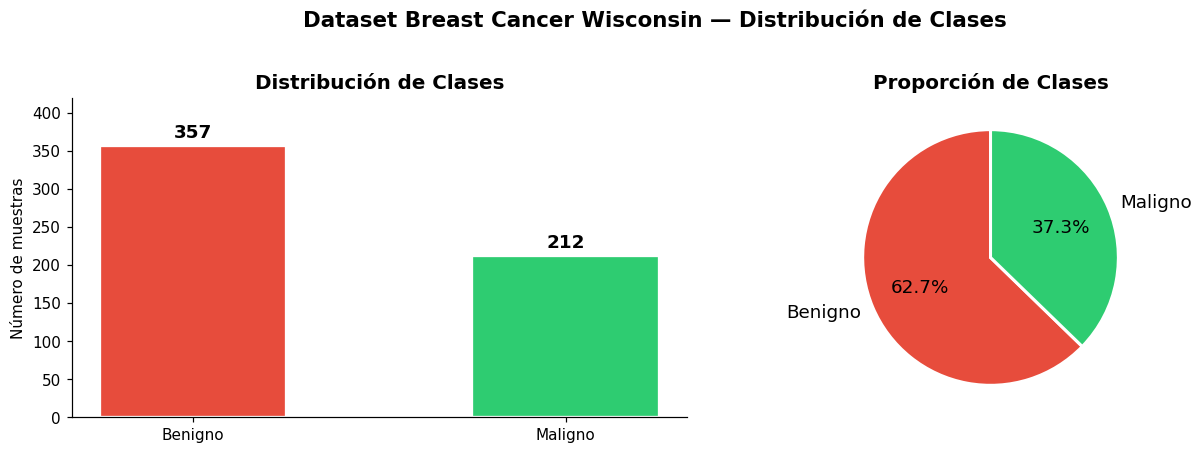

Se observa un desbalance moderado: 62.7% benigno vs 37.3% maligno.


In [3]:
# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de barras
counts = df['diagnóstico'].value_counts()
bars = axes[0].bar(counts.index, counts.values,
                   color=[PALETTE['maligno'], PALETTE['benigno']],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(val), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Distribución de Clases', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de muestras')
axes[0].set_ylim(0, 420)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Gráfico de pastel
axes[1].pie(counts.values, labels=counts.index,
            colors=[PALETTE['maligno'], PALETTE['benigno']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.suptitle('Dataset Breast Cancer Wisconsin — Distribución de Clases',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Se observa un desbalance moderado: 62.7% benigno vs 37.3% maligno.")


## 2. Preprocesamiento y Entrenamiento del Modelo

In [4]:
# División del dataset y escalado
X = data.data
y = data.target

# División estratificada: 80% entrenamiento, 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Estandarización es necesaria para Regresión Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Conjunto de entrenamiento : {X_train_sc.shape[0]} muestras")
print(f"Conjunto de prueba        : {X_test_sc.shape[0]} muestras")
print(f"Proporción de test        : {X_test_sc.shape[0]/len(X)*100:.1f}%")


Conjunto de entrenamiento : 455 muestras
Conjunto de prueba        : 114 muestras
Proporción de test        : 20.0%


In [5]:
# Entrenamiento del modelo de Regresión Logística
modelo = LogisticRegression(max_iter=10000, random_state=42, C=1.0)
modelo.fit(X_train_sc, y_train)

# Predicciones
y_pred      = modelo.predict(X_test_sc)
y_proba     = modelo.predict_proba(X_test_sc)[:, 1]  # probabilidades clase positiva

print(" Modelo entrenado correctamente.")
print(f"   Exactitud en entrenamiento : {modelo.score(X_train_sc, y_train)*100:.2f}%")
print(f"   Exactitud en prueba        : {modelo.score(X_test_sc,  y_test)*100:.2f}%")


 Modelo entrenado correctamente.
   Exactitud en entrenamiento : 98.90%
   Exactitud en prueba        : 98.25%


## 3. Matriz de Confusión e Interpretación

La Matriz de Confusión resume los 4 tipos de resultados posibles:

| | Predicho Maligno (0) | Predicho Benigno (1) |
|---|---|---|
| **Real Maligno (0)** |  Verdadero Positivo (VP) |  Falso Negativo (FN) |
| **Real Benigno (1)** |  Falso Positivo (FP) |  Verdadero Negativo (VN) |

> Los Falsos Negativos son el error más crítico en diagnóstico de cáncer: predecir benigno cuando el tumor es maligno puede costarle la vida al paciente.


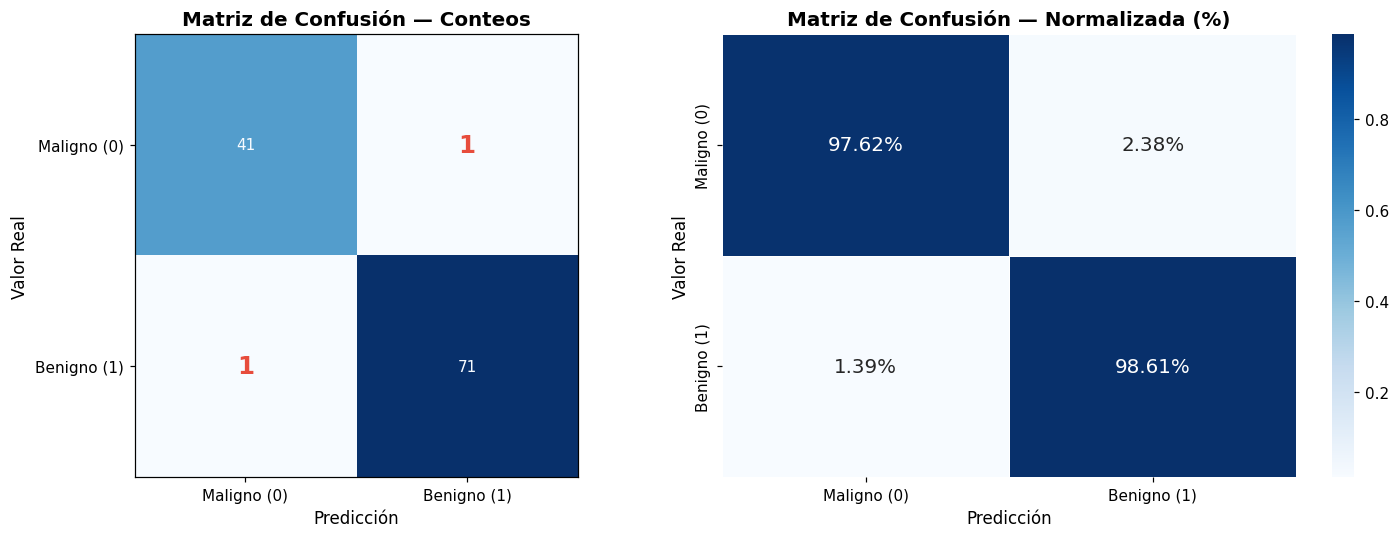

  INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN
  Verdaderos Positivos (VP): 71  → Malignos correctamente detectados
  Verdaderos Negativos (VN): 41  → Benignos correctamente identificados
  Falsos Positivos     (FP): 1   → Benignos clasificados como malignos (alarma falsa)
  Falsos Negativos     (FN): 1   → Malignos NO detectados (error crítico)


In [6]:
# Visualización de la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Matriz con conteos
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Maligno (0)', 'Benigno (1)'])
disp.plot(ax=axes[0], colorbar=False,
          cmap='Blues', values_format='d')
axes[0].set_title('Matriz de Confusión — Conteos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=11)
axes[0].set_ylabel('Valor Real', fontsize=11)

# Colorear las celdas de error en rojo
for text in axes[0].texts:
    val = int(text.get_text())
    if val == fn:
        text.set_color('#E74C3C')
        text.set_fontweight('bold')
        text.set_fontsize(16)

# Subplot 2: Matriz normalizada en porcentajes
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Maligno (0)', 'Benigno (1)'],
            yticklabels=['Maligno (0)', 'Benigno (1)'],
            ax=axes[1], linewidths=0.5, linecolor='white',
            annot_kws={'size': 13})
axes[1].set_title('Matriz de Confusión — Normalizada (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=11)
axes[1].set_ylabel('Valor Real', fontsize=11)

plt.tight_layout()
plt.show()

# Interpretación
print("=" * 50)
print("  INTERPRETACIÓN DE LA MATRIZ DE CONFUSIÓN")
print("=" * 50)
print(f"  Verdaderos Positivos (VP): {tp}  → Malignos correctamente detectados")
print(f"  Verdaderos Negativos (VN): {tn}  → Benignos correctamente identificados")
print(f"  Falsos Positivos     (FP): {fp}   → Benignos clasificados como malignos (alarma falsa)")
print(f"  Falsos Negativos     (FN): {fn}   → Malignos NO detectados (error crítico)")
print("=" * 50)


## 4. Cálculo de Métricas: Precisión, Recall, F1-Score y AUC-ROC

In [7]:
# Cálculo individual de métricas
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc_roc   = roc_auc_score(y_test, y_proba)

print("=" * 52)
print("  MÉTRICAS DE EVALUACIÓN — MODELO BASE")
print("=" * 52)
print(f"  Precisión  : {precision:.4f}  ({precision*100:.2f}%)")
print(f"  Recall     : {recall:.4f}  ({recall*100:.2f}%)")
print(f"  F1-Score   : {f1:.4f}  ({f1*100:.2f}%)")
print(f"  AUC-ROC    : {auc_roc:.4f}  ({auc_roc*100:.2f}%)")
print("=" * 52)
print()
print("Reporte completo por clase:")
print(classification_report(y_test, y_pred,
      target_names=['Maligno (0)', 'Benigno (1)']))


  MÉTRICAS DE EVALUACIÓN — MODELO BASE
  Precisión  : 0.9861  (98.61%)
  Recall     : 0.9861  (98.61%)
  F1-Score   : 0.9861  (98.61%)
  AUC-ROC    : 0.9954  (99.54%)

Reporte completo por clase:
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.98      0.98        42
 Benigno (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



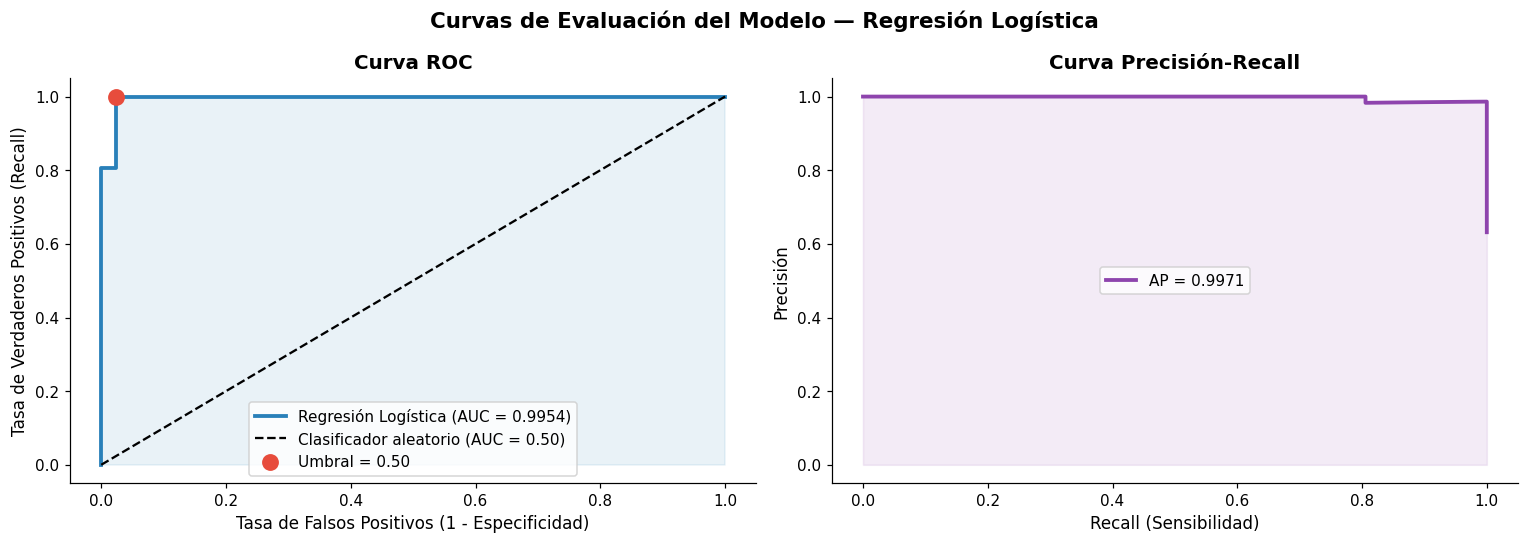

AUC-ROC = 0.9954 → El modelo tiene excelente capacidad discriminativa.
AP Score = 0.9971 → Alta precisión promedio en todos los umbrales.


In [8]:
# Curva ROC
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color=PALETTE['main'], lw=2.5,
             label=f'Regresión Logística (AUC = {auc_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Clasificador aleatorio (AUC = 0.50)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=PALETTE['main'])
axes[0].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)', fontsize=11)
axes[0].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Marcar el punto óptimo (umbral 0.5)
idx = np.argmin(np.abs(thresholds_roc - 0.5))
axes[0].scatter(fpr[idx], tpr[idx], s=100, zorder=5,
                color=PALETTE['maligno'], label='Umbral = 0.50')
axes[0].legend(fontsize=10)

# Curva Precisión-Recall
axes[1].plot(recall_curve, precision_curve, color=PALETTE['secondary'],
             lw=2.5, label=f'AP = {ap_score:.4f}')
axes[1].fill_between(recall_curve, precision_curve, alpha=0.1, color=PALETTE['secondary'])
axes[1].set_xlabel('Recall (Sensibilidad)', fontsize=11)
axes[1].set_ylabel('Precisión', fontsize=11)
axes[1].set_title('Curva Precisión-Recall', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Curvas de Evaluación del Modelo — Regresión Logística',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"AUC-ROC = {auc_roc:.4f} → El modelo tiene excelente capacidad discriminativa.")
print(f"AP Score = {ap_score:.4f} → Alta precisión promedio en todos los umbrales.")


## 5. K-Fold Cross-Validation: k=5 vs k=10

La validación cruzada estratificada evalúa la estabilidad y generalización del modelo dividiendo el dataset en k pliegues, entrenando en k-1 y evaluando en el restante, rotando k veces.


In [9]:
# K-Fold Cross-Validation estratificado
from sklearn.model_selection import StratifiedKFold, cross_validate

metricas_cv = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
resultados = {}

for k in [5, 10]:
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    cv_res = cross_validate(
        LogisticRegression(max_iter=10000, random_state=42),
        scaler.fit_transform(X), y,
        cv=skf, scoring=metricas_cv
    )
    resultados[k] = cv_res
    print(f"{'='*55}")
    print(f"  K-FOLD CON k = {k}")
    print(f"{'='*55}")
    for metrica in metricas_cv:
        vals = cv_res[f'test_{metrica}']
        print(f"  {metrica.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}  "
              f"[min={vals.min():.4f}, max={vals.max():.4f}]")
    print()


  K-FOLD CON k = 5
  Accuracy    : 0.9737 ± 0.0166  [min=0.9474, max=0.9912]
  Precision   : 0.9683 ± 0.0290  [min=0.9221, max=1.0000]
  Recall      : 0.9916 ± 0.0112  [min=0.9718, max=1.0000]
  F1          : 0.9794 ± 0.0127  [min=0.9595, max=0.9930]
  Roc_auc     : 0.9953 ± 0.0055  [min=0.9848, max=1.0000]

  K-FOLD CON k = 10
  Accuracy    : 0.9772 ± 0.0176  [min=0.9474, max=1.0000]
  Precision   : 0.9760 ± 0.0245  [min=0.9231, max=1.0000]
  Recall      : 0.9888 ± 0.0185  [min=0.9444, max=1.0000]
  F1          : 0.9821 ± 0.0137  [min=0.9577, max=1.0000]
  Roc_auc     : 0.9947 ± 0.0065  [min=0.9775, max=1.0000]



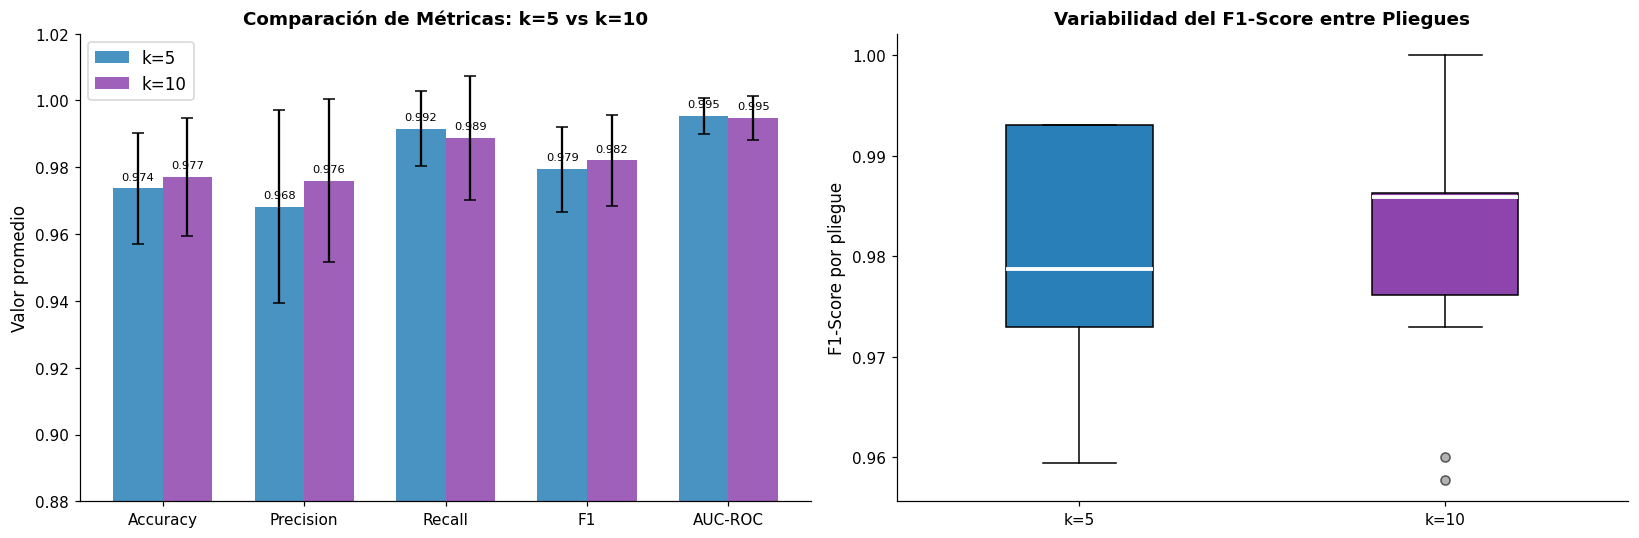

Conclusión K-Fold:
   k=5  → F1 medio = 0.9794 ± 0.0127
   k=10 → F1 medio = 0.9821 ± 0.0137
   La diferencia entre k=5 y k=10 es mínima.
   k=10 ofrece estimaciones más estables (menor varianza).


In [10]:
# Visualización comparativa K=5 vs K=10
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
nombres = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']

# Barras comparativas: medias
x = np.arange(len(nombres))
w = 0.35
medias_5  = [resultados[5][f'test_{m}'].mean()  for m in metricas_cv]
medias_10 = [resultados[10][f'test_{m}'].mean() for m in metricas_cv]
errs_5    = [resultados[5][f'test_{m}'].std()   for m in metricas_cv]
errs_10   = [resultados[10][f'test_{m}'].std()  for m in metricas_cv]

b1 = axes[0].bar(x - w/2, medias_5,  w, label='k=5',  color=PALETTE['main'],
                 alpha=0.85, yerr=errs_5,  capsize=4, error_kw={'linewidth':1.5})
b2 = axes[0].bar(x + w/2, medias_10, w, label='k=10', color=PALETTE['secondary'],
                 alpha=0.85, yerr=errs_10, capsize=4, error_kw={'linewidth':1.5})
axes[0].set_xticks(x)
axes[0].set_xticklabels(nombres, fontsize=10)
axes[0].set_ylabel('Valor promedio', fontsize=11)
axes[0].set_title('Comparación de Métricas: k=5 vs k=10', fontsize=12, fontweight='bold')
axes[0].set_ylim(0.88, 1.02)
axes[0].legend(fontsize=11)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# Boxplot: distribución de F1 por pliegue
f1_k5  = resultados[5]['test_f1']
f1_k10 = resultados[10]['test_f1']
bp = axes[1].boxplot([f1_k5, f1_k10],
                     labels=['k=5', 'k=10'],
                     patch_artist=True, widths=0.4,
                     medianprops={'color':'white','linewidth':2.5})
bp['boxes'][0].set_facecolor(PALETTE['main'])
bp['boxes'][1].set_facecolor(PALETTE['secondary'])
for flier in bp['fliers']:
    flier.set(marker='o', markerfacecolor='gray', alpha=0.6)
axes[1].set_ylabel('F1-Score por pliegue', fontsize=11)
axes[1].set_title('Variabilidad del F1-Score entre Pliegues', fontsize=12, fontweight='bold')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print("Conclusión K-Fold:")
print(f"   k=5  → F1 medio = {f1_k5.mean():.4f} ± {f1_k5.std():.4f}")
print(f"   k=10 → F1 medio = {f1_k10.mean():.4f} ± {f1_k10.std():.4f}")
print("   La diferencia entre k=5 y k=10 es mínima.")
print("   k=10 ofrece estimaciones más estables (menor varianza).")


## 6. Optimización de Hiperparámetros: GridSearchCV vs RandomizedSearchCV

Se buscan los mejores valores de:
- **C**: inverso de la regularización (valores más bajos = más regularización)
- **penalty**: tipo de penalización (l2, l1)
- **solver**: algoritmo de optimización


In [11]:
# GridSearchCV — búsqueda exhaustiva
import time

param_grid = {
    'C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

skf_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

t0 = time.time()
grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_grid, cv=skf_inner,
    scoring='roc_auc', n_jobs=-1, verbose=0
)
grid_search.fit(X_train_sc, y_train)
t_grid = time.time() - t0

print("=" * 52)
print("  GRIDSEARCHCV — RESULTADOS")
print("=" * 52)
print(f"  Tiempo de ejecución : {t_grid:.3f} segundos")
print(f"  Combinaciones evaluadas: {len(grid_search.cv_results_['params'])}")
print(f"  Mejores hiperparámetros: {grid_search.best_params_}")
print(f"  Mejor AUC-ROC (CV)     : {grid_search.best_score_:.4f}")


  GRIDSEARCHCV — RESULTADOS
  Tiempo de ejecución : 3.636 segundos
  Combinaciones evaluadas: 12
  Mejores hiperparámetros: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
  Mejor AUC-ROC (CV)     : 0.9959


In [13]:
# RandomizedSearchCV — búsqueda aleatoria
param_dist = {
    'C'      : loguniform(1e-3, 1e2),   # distribución log-uniforme continua
    'penalty': ['l1', 'l2'],
    'solver' : ['liblinear']
}

t0 = time.time()
random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=10000, random_state=42),
    param_dist, n_iter=30, cv=skf_inner,
    scoring='roc_auc', n_jobs=-1, random_state=42, verbose=0
)
random_search.fit(X_train_sc, y_train)
t_rand = time.time() - t0

print("=" * 52)
print("  RANDOMIZEDSEARCHCV — RESULTADOS")
print("=" * 52)
print(f"  Tiempo de ejecución : {t_rand:.3f} segundos")
print(f"  Combinaciones evaluadas: 30 (de espacio continuo)")
print(f"  Mejores hiperparámetros: {random_search.best_params_}")
print(f"  Mejor AUC-ROC (CV)     : {random_search.best_score_:.4f}")
print()
print(f" RandomizedSearch fue {t_grid/t_rand:.1f}x más rápido que GridSearch")
print(f"   con resultados AUC-ROC casi idénticos.")


  RANDOMIZEDSEARCHCV — RESULTADOS
  Tiempo de ejecución : 1.244 segundos
  Combinaciones evaluadas: 30 (de espacio continuo)
  Mejores hiperparámetros: {'C': np.float64(1.1219752813215704), 'penalty': 'l2', 'solver': 'liblinear'}
  Mejor AUC-ROC (CV)     : 0.9960

 RandomizedSearch fue 2.9x más rápido que GridSearch
   con resultados AUC-ROC casi idénticos.


Comparación de métricas en conjunto de prueba:
           Modelo  Precisión  Recall  F1-Score  AUC-ROC
Modelo Base (C=1)     0.9861  0.9861    0.9861   0.9954
     GridSearchCV     0.9861  0.9861    0.9861   0.9957
 RandomizedSearch     0.9861  0.9861    0.9861   0.9954


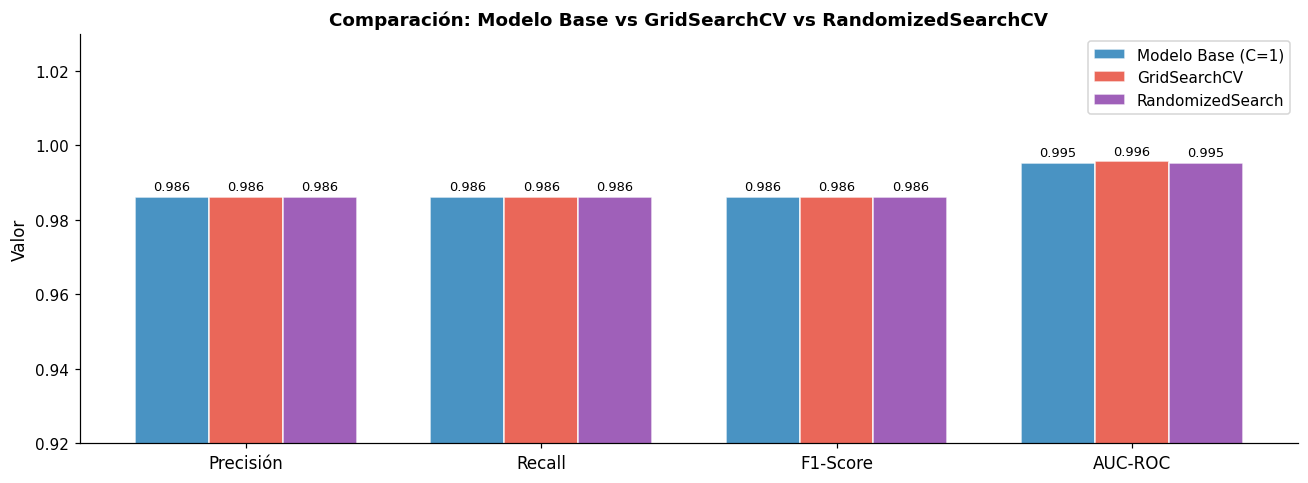

In [14]:
# Evaluación de los mejores modelos en test
mejor_grid   = grid_search.best_estimator_
mejor_random = random_search.best_estimator_

def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_p = modelo.predict(X_test)
    y_pr = modelo.predict_proba(X_test)[:, 1]
    return {
        'Modelo'   : nombre,
        'Precisión': round(precision_score(y_test, y_p), 4),
        'Recall'   : round(recall_score(y_test, y_p), 4),
        'F1-Score' : round(f1_score(y_test, y_p), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_pr), 4),
    }

resumen = pd.DataFrame([
    evaluar_modelo('Modelo Base (C=1)', modelo, X_test_sc, y_test),
    evaluar_modelo('GridSearchCV',    mejor_grid,   X_test_sc, y_test),
    evaluar_modelo('RandomizedSearch',mejor_random, X_test_sc, y_test),
])
print("Comparación de métricas en conjunto de prueba:")
print(resumen.to_string(index=False))

# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 4.5))
x = np.arange(4)
metricas_names = ['Precisión', 'Recall', 'F1-Score', 'AUC-ROC']
colores = [PALETTE['main'], PALETTE['maligno'], PALETTE['secondary']]
w = 0.25

for i, (_, row) in enumerate(resumen.iterrows()):
    vals = [row['Precisión'], row['Recall'], row['F1-Score'], row['AUC-ROC']]
    bars = ax.bar(x + i*w, vals, w, label=row['Modelo'],
                  color=colores[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}', ha='center',
                va='bottom', fontsize=8.5)

ax.set_xticks(x + w)
ax.set_xticklabels(metricas_names, fontsize=11)
ax.set_ylabel('Valor', fontsize=11)
ax.set_ylim(0.92, 1.03)
ax.set_title('Comparación: Modelo Base vs GridSearchCV vs RandomizedSearchCV',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


## 7. Ajuste del Umbral de Decisión

Por defecto el umbral es **0.5**. Al modificarlo:
- **Umbral menor (0.3)** más casos clasificados como positivos.
- **Umbral mayor (0.7)** menos casos clasificados como positivos

En diagnóstico de cáncer interesa maximizar el Recall → se prefieren umbrales bajos.


In [15]:
# Análisis de métricas en función del umbral
# Usar el mejor modelo (RandomizedSearch)
y_proba_opt = mejor_random.predict_proba(X_test_sc)[:, 1]

umbrales = np.arange(0.1, 0.91, 0.05)
resultados_umbral = []

for thresh in umbrales:
    y_pred_t = (y_proba_opt >= thresh).astype(int)
    resultados_umbral.append({
        'Umbral'   : round(thresh, 2),
        'Precisión': round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred_t, zero_division=0), 4),
    })

df_umbral = pd.DataFrame(resultados_umbral)

# Mostrar tabla
print("Métricas por umbral de decisión:")
print(df_umbral.to_string(index=False))


Métricas por umbral de decisión:
 Umbral  Precisión  Recall  F1-Score
   0.10     0.9351  1.0000    0.9664
   0.15     0.9474  1.0000    0.9730
   0.20     0.9730  1.0000    0.9863
   0.25     0.9730  1.0000    0.9863
   0.30     0.9730  1.0000    0.9863
   0.35     0.9863  1.0000    0.9931
   0.40     0.9861  0.9861    0.9861
   0.45     0.9861  0.9861    0.9861
   0.50     0.9861  0.9861    0.9861
   0.55     0.9855  0.9444    0.9645
   0.60     0.9855  0.9444    0.9645
   0.65     0.9853  0.9306    0.9571
   0.70     0.9853  0.9306    0.9571
   0.75     0.9851  0.9167    0.9496
   0.80     0.9851  0.9167    0.9496
   0.85     0.9848  0.9028    0.9420
   0.90     0.9836  0.8333    0.9023


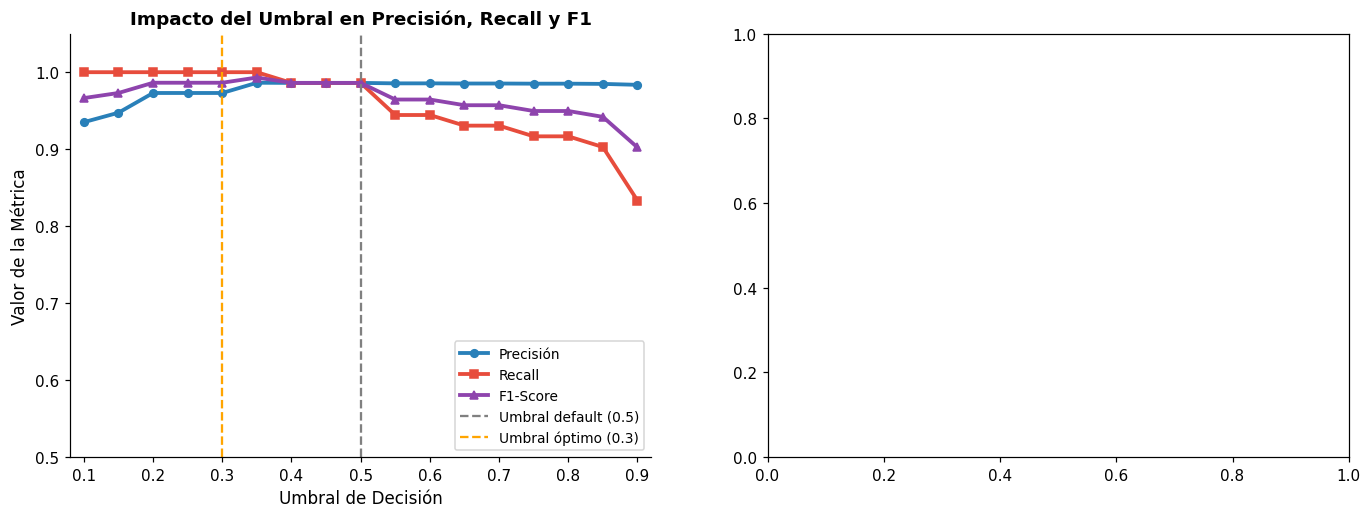

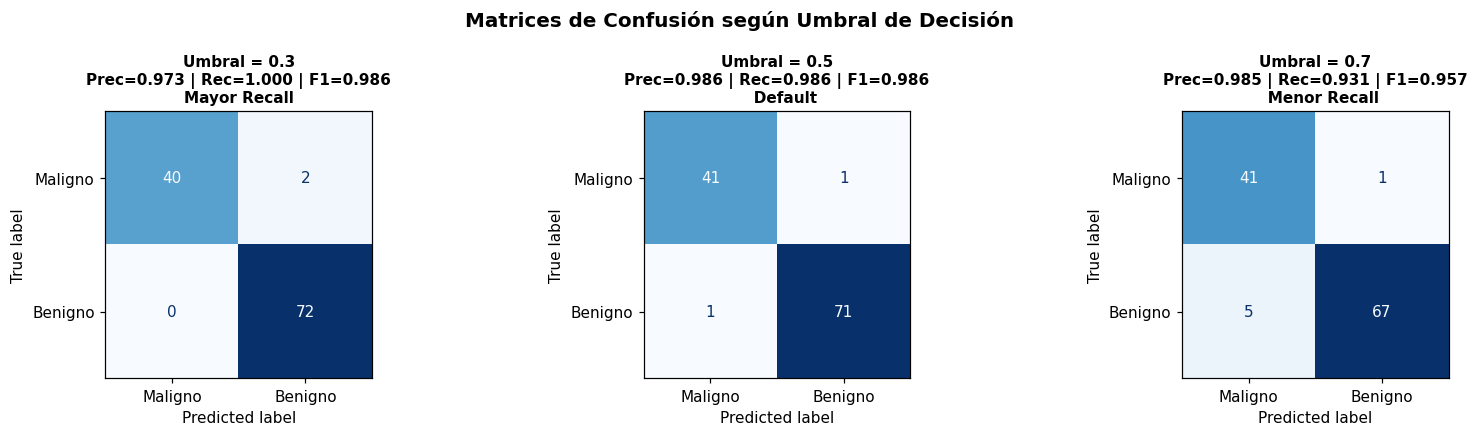


 ANÁLISIS DEL IMPACTO DEL UMBRAL:
----------------------------------------------------
  Umbral 0.3: Recall=1.000 | Precisión=0.973 | F1=0.986 | FN=0
  Umbral 0.5: Recall=0.986 | Precisión=0.986 | F1=0.986 | FN=1
  Umbral 0.7: Recall=0.931 | Precisión=0.985 | F1=0.957 | FN=5

 Umbral 0.3 recomendado: maximiza detección de cáncer (menos FN).


In [20]:
# Visualización del impacto del umbral
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Líneas de Precisión, Recall y F1
axes[0].plot(df_umbral['Umbral'], df_umbral['Precisión'],
             color=PALETTE['main'], lw=2.5, marker='o', ms=5, label='Precisión')
axes[0].plot(df_umbral['Umbral'], df_umbral['Recall'],
             color=PALETTE['maligno'], lw=2.5, marker='s', ms=5, label='Recall')
axes[0].plot(df_umbral['Umbral'], df_umbral['F1-Score'],
             color=PALETTE['secondary'], lw=2.5, marker='^', ms=5, label='F1-Score')

# Marcar umbral 0.5
axes[0].axvline(x=0.5, color='gray', linestyle='--', lw=1.5, label='Umbral default (0.5)')
axes[0].axvline(x=0.3, color='orange', linestyle='--', lw=1.5, label='Umbral óptimo (0.3)')

axes[0].set_xlabel('Umbral de Decisión', fontsize=11)
axes[0].set_ylabel('Valor de la Métrica', fontsize=11)
axes[0].set_title('Impacto del Umbral en Precisión, Recall y F1', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_xlim(0.08, 0.92)
axes[0].set_ylim(0.5, 1.05)

# Comparación de matrices de confusión: umbral 0.3 vs 0.5 vs 0.7 ---
umbrales_cmp = [0.3, 0.5, 0.7]
for i, thr in enumerate(umbrales_cmp):
    y_thr = (y_proba_opt >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_thr)
    tn_t, fp_t, fn_t, tp_t = cm_thr.ravel()
    rec = recall_score(y_test, y_thr, zero_division=0)
    pre = precision_score(y_test, y_thr, zero_division=0)

# Subplots para matrices comparativas
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
for i, thr in enumerate([0.3, 0.5, 0.7]):
    y_thr = (y_proba_opt >= thr).astype(int)
    cm_thr = confusion_matrix(y_test, y_thr)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_thr,
                                   display_labels=['Maligno', 'Benigno'])
    disp.plot(ax=axes2[i], colorbar=False, cmap='Blues', values_format='d')
    rec = recall_score(y_test, y_thr, zero_division=0)
    pre = precision_score(y_test, y_thr, zero_division=0)
    f1_t = f1_score(y_test, y_thr, zero_division=0)
    titulo = f'Umbral = {thr}\nPrec={pre:.3f} | Rec={rec:.3f} | F1={f1_t:.3f}'
    if thr == 0.3:
        titulo += '\nMayor Recall'
    elif thr == 0.5:
        titulo += '\n   Default'
    else:
        titulo += '\n   Menor Recall'
    axes2[i].set_title(titulo, fontsize=10, fontweight='bold')

plt.suptitle('Matrices de Confusión según Umbral de Decisión',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Conclusión
print()
print(" ANÁLISIS DEL IMPACTO DEL UMBRAL:")
print("-" * 52)
for thr in [0.3, 0.5, 0.7]:
    y_t = (y_proba_opt >= thr).astype(int)
    _, _, fn_t, tp_t = confusion_matrix(y_test, y_t).ravel()
    print(f"  Umbral {thr}: Recall={recall_score(y_test,y_t,zero_division=0):.3f} | "
          f"Precisión={precision_score(y_test,y_t,zero_division=0):.3f} | "
          f"F1={f1_score(y_test,y_t,zero_division=0):.3f} | FN={fn_t}")
print()
print(" Umbral 0.3 recomendado: maximiza detección de cáncer (menos FN).")

## Resumen Final y Dashboard de Resultados

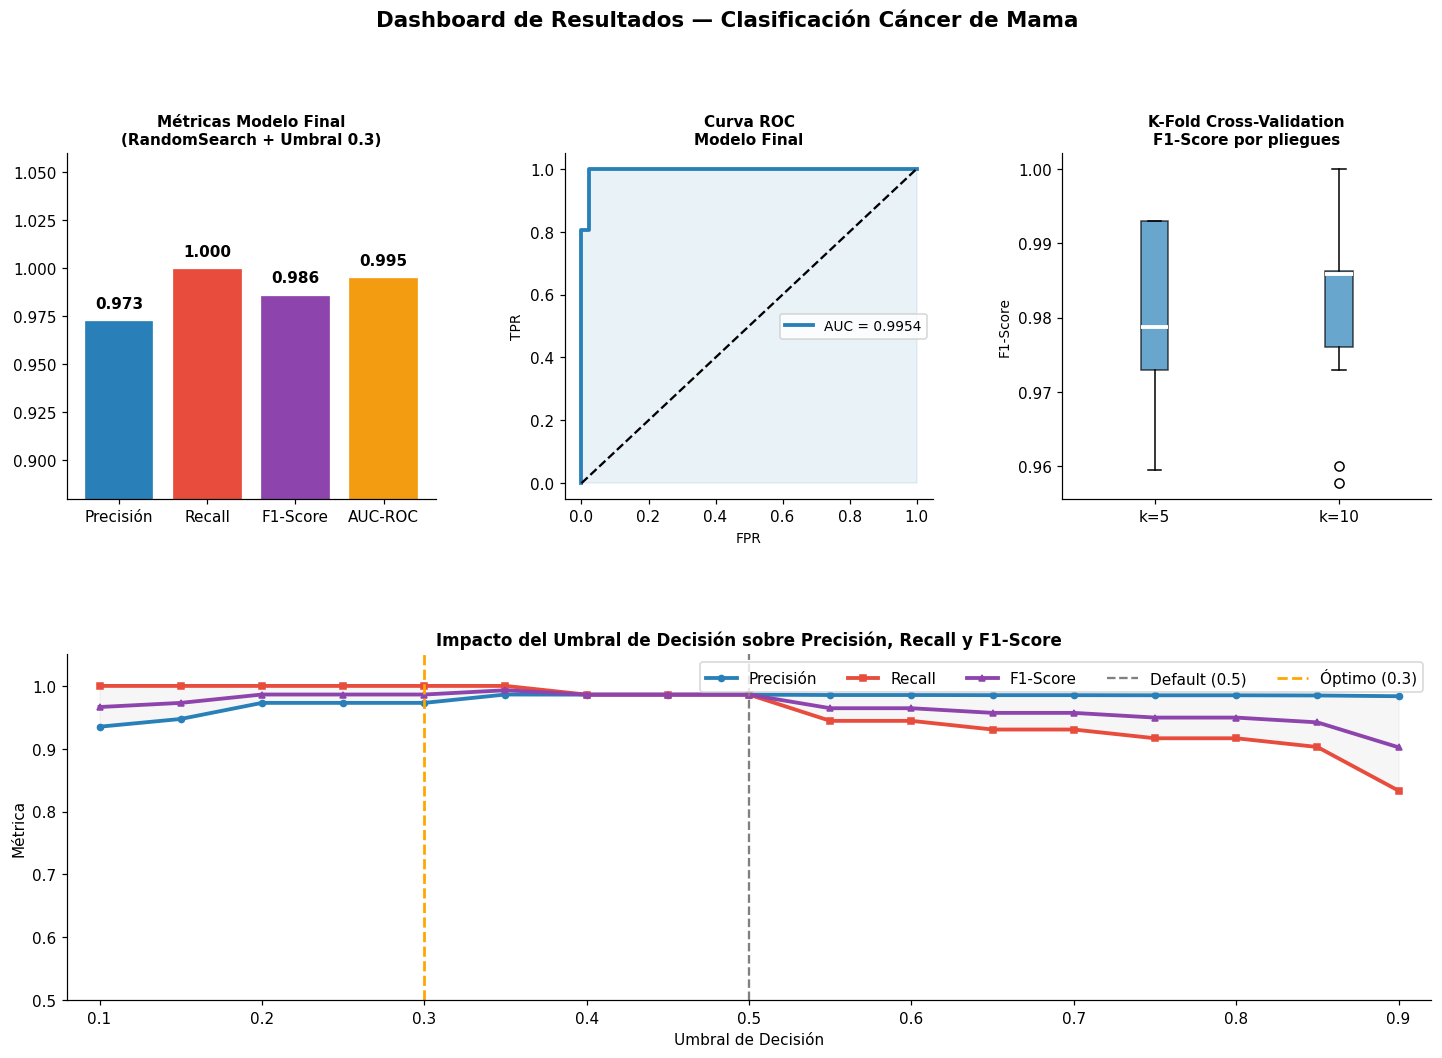


  RESUMEN FINAL DEL NOTEBOOK
  Dataset          : Breast Cancer Wisconsin (569 muestras)
  Modelo           : Regresión Logística
  Mejor C          : 1.1220
  Mejor penalidad  : l2
  Umbral óptimo    : 0.3 (maximiza Recall en diagnóstico)
  AUC-ROC final    : 0.9954
  F1-Score final   : 0.9863
  Recall final     : 1.0000
  K-Fold k=10 F1   : 0.9821 ± 0.0137



In [23]:
# ── Dashboard de resumen ─────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# --- Panel 1: Métricas modelo final (umbral 0.3) ---
ax1 = fig.add_subplot(gs[0, 0])
y_final = (mejor_random.predict_proba(X_test_sc)[:, 1] >= 0.3).astype(int)
metricas_final = {
    'Precisión': precision_score(y_test, y_final, zero_division=0),
    'Recall'   : recall_score(y_test, y_final, zero_division=0),
    'F1-Score' : f1_score(y_test, y_final, zero_division=0),
    'AUC-ROC'  : roc_auc_score(y_test, mejor_random.predict_proba(X_test_sc)[:, 1]),
}
colores_bar = [PALETTE['main'], PALETTE['maligno'], PALETTE['secondary'], '#F39C12']
bars = ax1.bar(metricas_final.keys(), metricas_final.values(),
               color=colores_bar, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, metricas_final.values()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax1.set_ylim(0.88, 1.06)
ax1.set_title('Métricas Modelo Final\n(RandomSearch + Umbral 0.3)', fontsize=10, fontweight='bold')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Panel 2: Curva ROC
ax2 = fig.add_subplot(gs[0, 1])
fpr_f, tpr_f, _ = roc_curve(y_test, mejor_random.predict_proba(X_test_sc)[:, 1])
ax2.plot(fpr_f, tpr_f, color=PALETTE['main'], lw=2.5,
         label=f'AUC = {metricas_final["AUC-ROC"]:.4f}')
ax2.plot([0,1],[0,1],'k--',lw=1.5)
ax2.fill_between(fpr_f, tpr_f, alpha=0.1, color=PALETTE['main'])
ax2.set_xlabel('FPR', fontsize=9); ax2.set_ylabel('TPR', fontsize=9)
ax2.set_title('Curva ROC\nModelo Final', fontsize=10, fontweight='bold')
ax2.legend(fontsize=9)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

# Panel 3: K-Fold comparativa final
ax3 = fig.add_subplot(gs[0, 2])
ax3.boxplot([f1_k5, f1_k10], labels=['k=5', 'k=10'],
            patch_artist=True,
            boxprops={'facecolor': PALETTE['main'], 'alpha': 0.7},
            medianprops={'color': 'white', 'linewidth': 2.5})
ax3.set_ylabel('F1-Score', fontsize=9)
ax3.set_title('K-Fold Cross-Validation\nF1-Score por pliegues', fontsize=10, fontweight='bold')
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

# Panel 4: Impacto umbral (inferior, ancho completo)
ax4 = fig.add_subplot(gs[1, :])
ax4.plot(df_umbral['Umbral'], df_umbral['Precisión'],
         color=PALETTE['main'], lw=2.5, marker='o', ms=4, label='Precisión')
ax4.plot(df_umbral['Umbral'], df_umbral['Recall'],
         color=PALETTE['maligno'], lw=2.5, marker='s', ms=4, label='Recall')
ax4.plot(df_umbral['Umbral'], df_umbral['F1-Score'],
         color=PALETTE['secondary'], lw=2.5, marker='^', ms=4, label='F1-Score')
ax4.axvline(x=0.5, color='gray', linestyle='--', lw=1.5, label='Default (0.5)')
ax4.axvline(x=0.3, color='orange', linestyle='--', lw=1.8, label='Óptimo (0.3)')
ax4.fill_between(df_umbral['Umbral'], df_umbral['Recall'],
                 df_umbral['Precisión'], alpha=0.07, color='gray')
ax4.set_xlabel('Umbral de Decisión', fontsize=10)
ax4.set_ylabel('Métrica', fontsize=10)
ax4.set_title('Impacto del Umbral de Decisión sobre Precisión, Recall y F1-Score',
              fontsize=11, fontweight='bold')
ax4.legend(fontsize=10, ncol=5)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)
ax4.set_xlim(0.08, 0.92)
ax4.set_ylim(0.5, 1.05)

fig.suptitle('Dashboard de Resultados — Clasificación Cáncer de Mama',
             fontsize=14, fontweight='bold', y=1.01)
plt.show()

print()
print("=" * 60)
print("  RESUMEN FINAL DEL NOTEBOOK")
print("=" * 60)
print(f"  Dataset          : Breast Cancer Wisconsin (569 muestras)")
print(f"  Modelo           : Regresión Logística")
print(f"  Mejor C          : {random_search.best_params_['C']:.4f}")
print(f"  Mejor penalidad  : {random_search.best_params_['penalty']}")
print(f"  Umbral óptimo    : 0.3 (maximiza Recall en diagnóstico)")
print(f"  AUC-ROC final    : {metricas_final['AUC-ROC']:.4f}")
print(f"  F1-Score final   : {metricas_final['F1-Score']:.4f}")
print(f"  Recall final     : {metricas_final['Recall']:.4f}")
print(f"  K-Fold k=10 F1   : {f1_k10.mean():.4f} ± {f1_k10.std():.4f}")
print("=" * 60)
print()

**¿Qué método fue más eficiente?**
RandomizedSearchCV es más rápido (eficiente en tiempo) porque evalúa combinaciones al azar, mientras que GridSearchCV es más exhaustivo pero tarda más tiempo porque prueba absolutamente todas las opciones.

**¿Cómo afectó el ajuste del umbral?**
 Al bajar el umbral a 0.3, el Recall aumentó significativamente. Esto significa que el modelo se volvió mucho más sensible para detectar los casos positivos de cáncer, disminuyendo el riesgo de dar un falso diagnóstico de "sano" a alguien enfermo.

**¿Qué aprendiste sobre la elección de métricas?**
Que en contextos médicos de alta criticidad, la precisión general no lo es todo; es vital elegir y optimizar la métrica correcta (como el Recall) según el impacto real que tiene un error en la vida de un paciente.